In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from skimage.color import rgb2gray

In [2]:
# Load dataset
data_dir = 'Plastic types'
image_size = (128, 128)

X = []
y = []

In [3]:
import cv2
import numpy as np
import random
from tqdm import tqdm

def augment_image(img):
    aug_imgs = []

    # 1. Horizontal Flip
    h_flip = cv2.flip(img, 1)
    aug_imgs.append(h_flip)

    # 2. Rotation (+15 and -15 derajat)
    h, w = img.shape[:2]
    for angle in [-15, 15]:
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        rotated = cv2.warpAffine(img, M, (w, h))
        aug_imgs.append(rotated)

    # 3. Brightness adjust
    bright = cv2.convertScaleAbs(img, alpha=1.2, beta=30)  # cerahin dikit
    dark = cv2.convertScaleAbs(img, alpha=0.8, beta=-30)  # gelapin dikit
    aug_imgs.extend([bright, dark])

    # 4. Zoom (crop tengah lalu resize balik)
    crop = img[10:-10, 10:-10]  # crop pinggir
    zoom = cv2.resize(crop, (w, h))
    aug_imgs.append(zoom)

    # 5. Blur
    blur = cv2.GaussianBlur(img, (5,5), 0)
    aug_imgs.append(blur)

    return aug_imgs

In [4]:
def extract_feature(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8],
                        [0, 180, 0, 256, 0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

In [5]:
# Load image dan ekstraksi HOG
# for label in os.listdir(data_dir):
#     class_dir = os.path.join(data_dir, label)
#     if not os.path.isdir(class_dir):
#         continue
#     for img_file in os.listdir(class_dir):
#         img_path = os.path.join(class_dir, img_file)
#         img = cv2.imread(img_path)
#         if img is not None:
#             img = cv2.resize(img, image_size)
#             gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#             # Ekstrak fitur HOG
#             features, _ = hog(
#                 gray,
#                 orientations=9,
#                 pixels_per_cell=(8, 8),
#                 cells_per_block=(2, 2),
#                 block_norm='L2-Hys',
#                 visualize=True
#             )
#             X.append(features)
#             y.append(label)

X = []
y = []

for label in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, label)
    if not os.path.isdir(class_dir):
        continue
    for img_file in tqdm(os.listdir(class_dir), desc=f"Augmenting {label}"):
        img_path = os.path.join(class_dir, img_file)
        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, image_size)

            # Tambahkan gambar original
            feature = extract_feature(img)  # kamu bikin sendiri, misal histogram/hog
            X.append(feature)
            y.append(label)

            # Tambahkan augmented images
            aug_imgs = augment_image(img)
            for aug in aug_imgs:
                feature_aug = extract_feature(aug)
                X.append(feature_aug)
                y.append(label)
        except:
            continue


Augmenting PS: 100%|██████████| 527/527 [00:13<00:00, 39.39it/s]


In [6]:
# Convert ke numpy array
X = np.array(X)
y = np.array(y)

In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [8]:
# Data split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [9]:
# Scaling fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, multi_class='multinomial')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [11]:
# Prediksi
y_pred = clf.predict(X_test)

In [12]:
# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.4101633393829401
Classification Report:
               precision    recall  f1-score   support

      Others       0.41      0.46      0.43       826
          PC       0.42      0.28      0.34       771
          PE       0.48      0.38      0.42       802
         PET       0.43      0.51      0.46       933
          PP       0.34      0.43      0.38       805
          PS       0.41      0.37      0.39       822

    accuracy                           0.41      4959
   macro avg       0.42      0.41      0.41      4959
weighted avg       0.42      0.41      0.41      4959



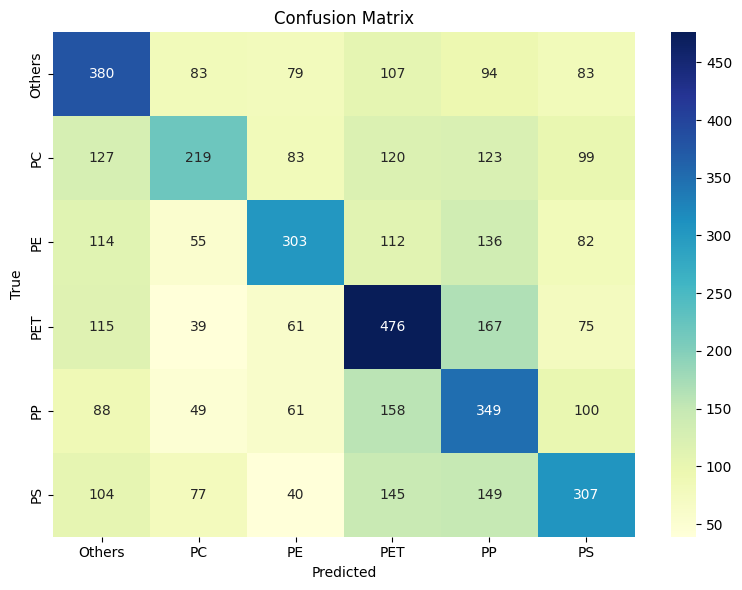

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [14]:
import pickle

# Save model
with open('model_lr.pkl', 'wb') as f:
    pickle.dump(clf, f)

In [15]:
# # Load model
# with open('model_svm.pkl', 'rb') as f:
#     model = pickle.load(f)